In [4]:
# Check for Duplicates in 'Lien' Column
import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
df = pd.read_csv('../csv/STEP01_maisons_dept29.csv', encoding='utf-8')
display("Number of duplicated links:", df['Lien'].duplicated().sum())
duplicates = df[df['Lien'].duplicated(keep=False)].sort_values(by='Lien')
display(duplicates)

'Number of duplicated links:'

np.int64(0)

,Ville,Nom,Lien


In [9]:
# Extraire toutes les villes du département 29 depuis code_insee.csv et créer un nouveau CSV
import pandas as pd

# Charger le fichier code_insee.csv
df_insee = pd.read_csv('../csv/code_insee.csv', encoding='utf-8')

# Filtrer pour le département 56
df_dept56 = df_insee[df_insee['DEP'] == '56']

# Sauvegarder dans un nouveau CSV
df_dept56.to_csv('../csv/communes_dept56.csv', index=False, encoding='utf-8')

print(f"Nombre de communes dans le département 56: {len(df_dept56)}")
print("Nouveau CSV créé: ../csv/communes_dept56.csv")

Nombre de communes dans le département 56: 344
Nouveau CSV créé: ../csv/communes_dept56.csv


,Nom,Lien,Prix,Lieu,Taille,Taille_terrain,Pieces
2484,""" vendu par kerebel immobilier """,https://www.etreproprio.com/immobilier-6352416...,312 500,Loperhet 29470,1.0,2 692,6.0
1189,Moulin 29900 + gites-16 pièce(s) 239 m2,https://www.etreproprio.com/immobilier-2129764...,1 170 876,Concarneau 29900,239.0,62 288,16.0
2521,Melgven - moulin avec maison principale et 3 g...,https://www.etreproprio.com/immobilier-2048510...,1 163 000,Melgven 29140,239.0,62 288,16.0
2557,Maison moëlan sur mer 11 pièces 237 m2 proche ...,https://www.etreproprio.com/immobilier-2383865...,391 875,Moelan-Sur-Mer 29350,239.0,670,11.0
3077,Maison 239m² à plomeur,https://www.etreproprio.com/immobilier-2355834...,598 500,Plomeur 29120,239.0,1 150,7.0
...,...,...,...,...,...,...,...
504,Villa - alhambra - 12 chambres - nueva andalucia,https://www.etreproprio.com/immobilier-1927051...,10 850 000,Carantec 29660,1467.0,NaN,14.0
2735,Las lomas del marbella club - golden mile,https://www.etreproprio.com/immobilier-1927052...,n.c.,Morlaix 29600,2000.0,NaN,32.0
649,A vendre hameau chateaulin,https://www.etreproprio.com/immobilier-1942440...,945 000,Chateaulin 29150,4100.0,233 567,NaN
4638,Maison 11243m² à quimper,https://www.etreproprio.com/immobilier-2271569...,245 920,Quimper 29000,11243.0,407,5.0


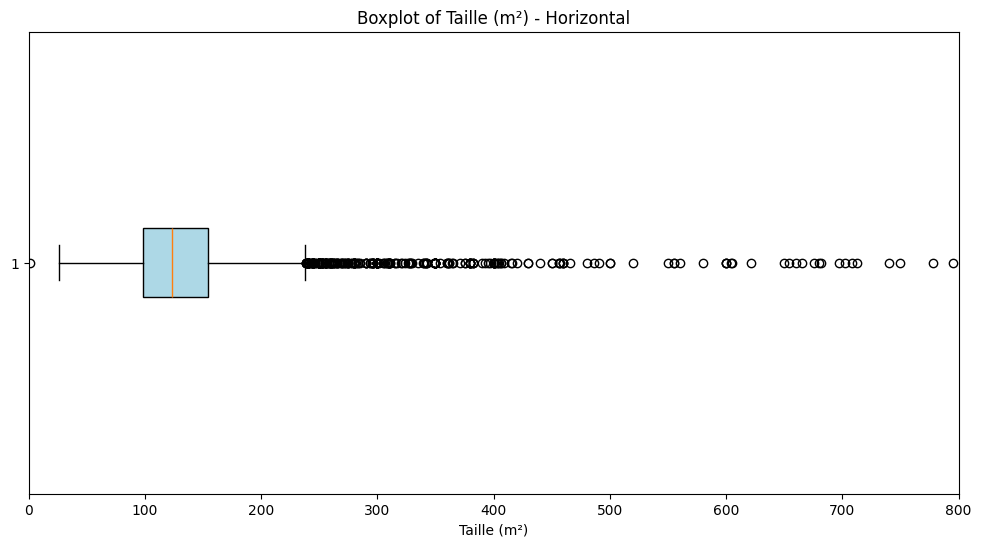

In [27]:
import pandas as pd

# Load the CSV
df = pd.read_csv('../csv/STEP02_maisons_dept29.csv', encoding='utf-8')

# Convert columns to numeric, handling errors
df['Taille'] = pd.to_numeric(df['Taille'].astype(str).str.replace(' ', ''), errors='coerce')

# Function to detect outliers using IQR
def detect_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return series[(series < lower_bound) | (series > upper_bound)]

# Find outliers in 'Taille'
taille_outliers = detect_outliers(df['Taille'].dropna())

# Display the rows with outliers
outlier_rows = df[df['Taille'].isin(taille_outliers)].sort_values(by='Taille')
display(outlier_rows)

# Graphical display of outliers using matplotlib
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.boxplot(df['Taille'].dropna(), vert=False, patch_artist=True, boxprops=dict(facecolor='lightblue'))
plt.title('Boxplot of Taille (m²) - Horizontal')
plt.xlabel('Taille (m²)')
plt.xlim(0, 800)  # Adjust xlim to show the outlier at 75000
plt.show()

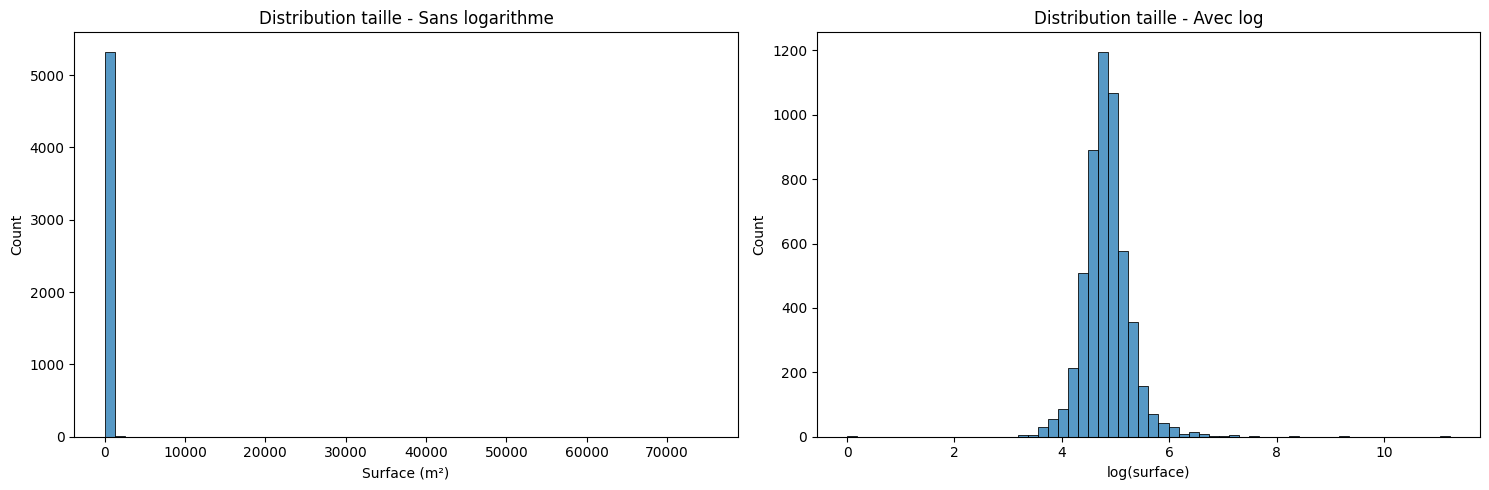

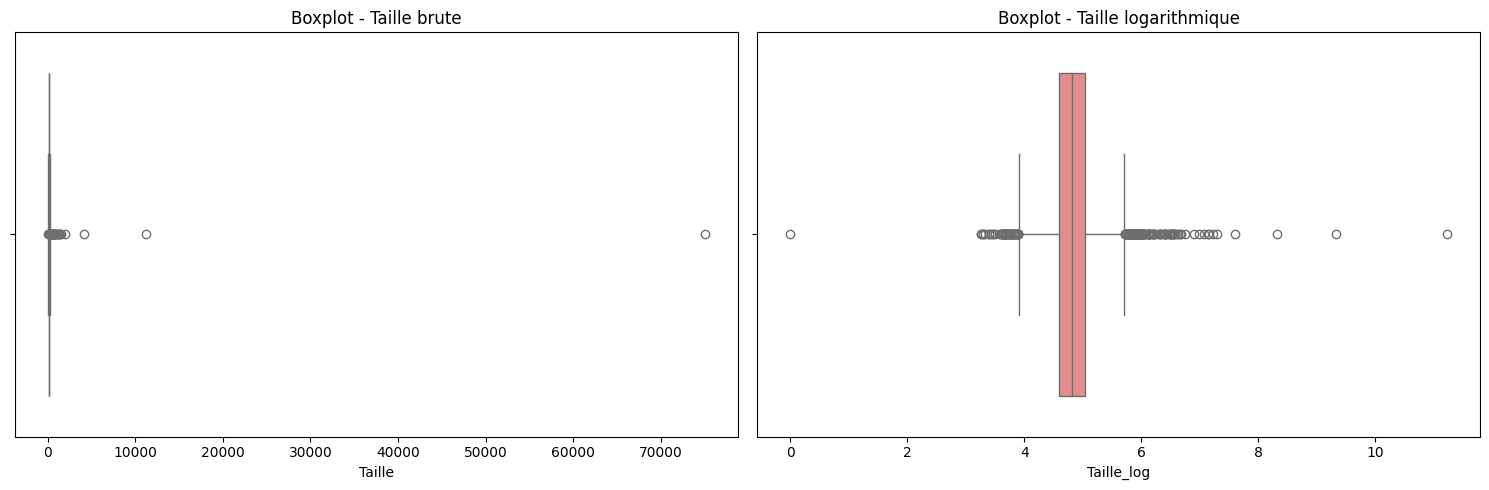

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load CSV
df = pd.read_csv('../csv/STEP02_maisons_dept29.csv', encoding='utf-8')

# Nettoyage numérique
df['Taille'] = pd.to_numeric(df['Taille'].astype(str).str.replace(' ', ''), errors='coerce')

# Création colonne logarithmique (⚠ ignore <=0 pour le log)
df['Taille_log'] = np.log(df['Taille'].replace(0, np.nan))

# --------- 📊 Visualisation histogrammes ------------------
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
sns.histplot(df['Taille'].dropna(), bins=60)
plt.title("Distribution taille - Sans logarithme")
plt.xlabel("Surface (m²)")

plt.subplot(1,2,2)
sns.histplot(df['Taille_log'].dropna(), bins=60)
plt.title("Distribution taille - Avec log")
plt.xlabel("log(surface)")

plt.tight_layout()
plt.show()

# --------- 📦 Boxplots comparés ------------------
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
sns.boxplot(x=df['Taille'].dropna(), color="skyblue")
plt.title("Boxplot - Taille brute")

plt.subplot(1,2,2)
sns.boxplot(x=df['Taille_log'].dropna(), color="lightcoral")
plt.title("Boxplot - Taille logarithmique")

plt.tight_layout()
plt.show()
